# Tree-DTW playground

Interactive tests + visualization for `network_matching.tree_dtw.match_tree_to_bgraph` — the
**standalone** matcher of a directed source *tree* onto a directed target network
(spec: `docs/tree_dtw_matching.md`). It builds the forward `D` / backward `B` cost tables, does the
joint `D+B−E` traceback, and returns the **matching relation `M`** (a set of `(a_point, b_point)`
pairs; a 1:N coverage run gives a point several pairs). No DAG matcher is involved.

Each figure: **blue** = source tree `A`, **orange** = target network `B`, thin lines = the
correspondence `M` (colored by drift).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import LineString
from network_matching.tree_dtw import match_tree_to_bgraph, check_tree_rules
from network_matching.dag_synthetic import get_dag
%matplotlib inline

In [2]:
def _ls(edges):
    return [(e, g if hasattr(g, "coords") else LineString(g)) for e, g in edges]

def summarize(res):
    runs = [len(m["run"]) for m in res["a_match"]]
    print("routes:", res["routes"])
    if "rules" in res:
        print("valid (V1-V4):", res["rules"]["ok"],
              "" if res["rules"]["ok"] else {k: v for k, v in res["rules"].items() if k != "ok" and v})
    print(f"M: {len(res['M'])} pairs over {len(res['a_match'])} source points; "
          f"max coverage run = {max(runs)} (a run > 1 is a 1:N match)")

def plot_match(res, a_edges, b_edges, title="", show_runs=True):
    ga, gb = res["GA"], res["GB"]
    fig, ax = plt.subplots(figsize=(9, 5))
    for _e, g in _ls(b_edges):
        xs, ys = zip(*g.coords); ax.plot(xs, ys, "-", color="#e8964a", lw=4, alpha=.6, zorder=1)
    for _e, g in _ls(a_edges):
        xs, ys = zip(*g.coords); ax.plot(xs, ys, "-", color="#3b6ea5", lw=2, zorder=2)
    dmax = max((m["drift"] for m in res["a_match"]), default=1.0) or 1.0
    for m in res["a_match"]:
        if show_runs:
            for w in m["run"]:
                ax.plot([m["ax"], gb.vx[w]], [m["ay"], gb.vy[w]], "-", color="0.85", lw=.6, zorder=1)
        ax.plot([m["ax"], m["bx"]], [m["ay"], m["by"]], "-",
                color=plt.cm.viridis(min(m["drift"] / dmax, 1.0)), lw=1.1, zorder=3)
    ax.scatter([m["ax"] for m in res["a_match"]], [m["ay"] for m in res["a_match"]],
               s=14, color="#3b6ea5", zorder=4, label="A points")
    ax.scatter(gb.vx, gb.vy, s=9, color="#e8964a", alpha=.6, zorder=4, label="B points")
    ax.set_aspect("equal"); ax.set_title(title); ax.legend(loc="best", fontsize=8); plt.show()

## 1. A branching source (`y_split`)
One road splits into two; the B network splits the same way.

routes: {'A_main': ['B_main'], 'A_left': ['B_left'], 'A_right': ['B_right']}
valid (V1-V4): True 
M: 32 pairs over 31 source points; max coverage run = 2 (a run > 1 is a 1:N match)


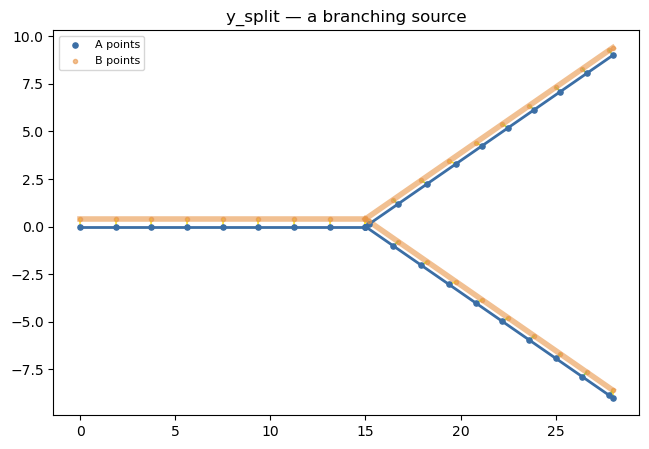

In [3]:
sc = get_dag("y_split")
res = match_tree_to_bgraph(sc["a_edges"], sc["b_edges"], snap_tolerance_m=0.5, step_meters=2.0, validate=True)
summarize(res)
plot_match(res, sc["a_edges"], sc["b_edges"], "y_split — a branching source")

## 2. A merge
Two roads join into one; the incoming B-tails belong to the upstream branches, the merge point to `A_out`.

routes: {'A_bot': ['B_bot'], 'A_top': ['B_top'], 'A_out': ['B_out']}
valid (V1-V4): True 
M: 34 pairs over 33 source points; max coverage run = 2 (a run > 1 is a 1:N match)


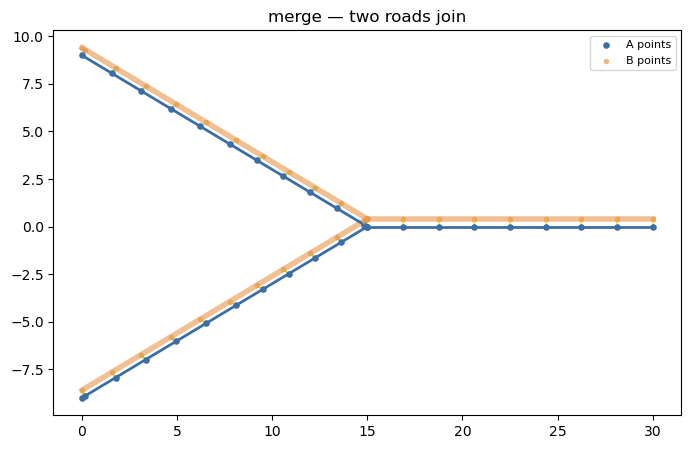

In [4]:
sc = get_dag("merge")
res = match_tree_to_bgraph(sc["a_edges"], sc["b_edges"], snap_tolerance_m=0.5, step_meters=2.0, validate=True)
summarize(res)
plot_match(res, sc["a_edges"], sc["b_edges"], "merge — two roads join")

## 3. Coverage weight `α`
`α ≤ 1` discounts the emission on a horizontal (1:N) coverage step, so it stays cheap when B is sampled finer than A. `α = 1` is the plain per-point charge. The matching stays valid at every `α`.

In [5]:
sc = get_dag("merge")
for a in (1.0, 0.5, 0.2):
    r = match_tree_to_bgraph(sc["a_edges"], sc["b_edges"], snap_tolerance_m=0.5, step_meters=2.0,
                             horizontal_weight=a, validate=True)
    runs = [len(m["run"]) for m in r["a_match"]]
    print(f"alpha={a}:  valid={r['rules']['ok']}  pairs={len(r['M'])}  max_run={max(runs)}")

alpha=1.0:  valid=True  pairs=34  max_run=2


alpha=0.5:  valid=True  pairs=34  max_run=2
alpha=0.2:  valid=True  pairs=34  max_run=2


## 4. Perturbation
Rigidly shift the whole tree north (junctions stay stitched) and re-match.

routes: {'A_main': ['B_main'], 'A_left': ['B_left'], 'A_right': ['B_right']}
valid (V1-V4): True 
M: 32 pairs over 30 source points; max coverage run = 2 (a run > 1 is a 1:N match)


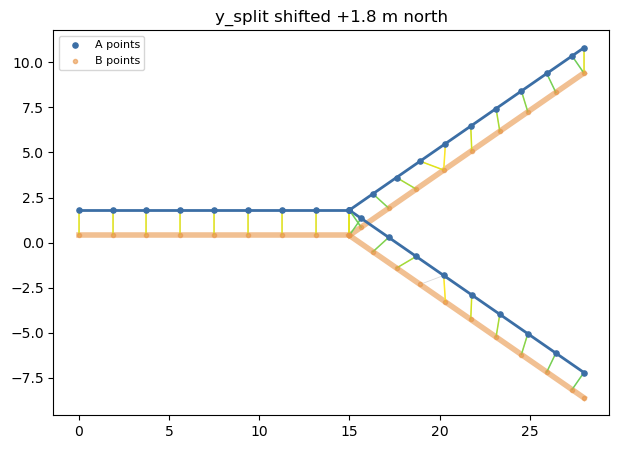

In [6]:
sc = get_dag("y_split")
A = [(e, LineString([(x, y + 1.8) for x, y in g.coords])) for e, g in sc["a_edges"]]
res = match_tree_to_bgraph(A, sc["b_edges"], snap_tolerance_m=0.5, step_meters=2.0, validate=True)
summarize(res)
plot_match(res, A, sc["b_edges"], "y_split shifted +1.8 m north")

## 5. Build your own tree
Edges are plain coordinate lists; coincident endpoints get stitched into junctions.

routes: {'stem': ['stem'], 'down': ['down'], 'up': ['up']}
valid (V1-V4): True 
M: 31 pairs over 29 source points; max coverage run = 2 (a run > 1 is a 1:N match)


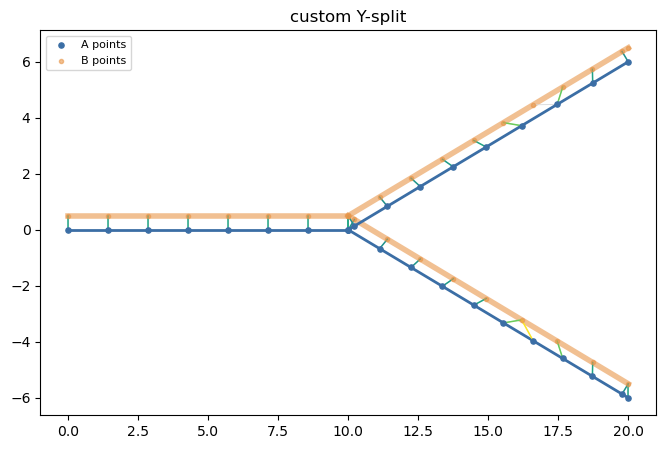

In [7]:
a_edges = [("stem", [(0, 0), (10, 0)]),
           ("up",   [(10, 0), (20, 6)]),
           ("down", [(10, 0), (20, -6)])]
b_edges = [("stem", [(0, 0.5), (10, 0.5)]),
           ("up",   [(10, 0.5), (20, 6.5)]),
           ("down", [(10, 0.5), (20, -5.5)])]
res = match_tree_to_bgraph(a_edges, b_edges, snap_tolerance_m=0.75, step_meters=1.5, validate=True)
summarize(res)
plot_match(res, a_edges, b_edges, "custom Y-split")